# Stochastic weather and trend detection

A WGEN-type generator (Richardson, 1981) with:
- Markov-chain precipitation;
- AR(1) temperature anomalies around an annual cycle;
- an optional warming trend.

We recover the parameters and show why the standard errors of a trend
estimate must account for autocorrelation.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pcc_vizforge.plots.style import apply_matplotlib_style

apply_matplotlib_style()
SEED = 20240101

In [2]:
from pcc_vizforge.generators import WeatherGenerator
from pcc_vizforge.analysis import timeseries

gen = WeatherGenerator(n_days=365 * 30 + 7, warming_trend_c_per_decade=0.3)
wx = gen.generate(seed=SEED)
wx.head()

,date,day_of_year,temperature_avg,temperature_morning,temperature_afternoon,temperature_evening,temperature_night,temperature_min,temperature_max,temperature_anomaly,...,precipitation,wind_speed,pressure,cloud_cover,season,weather_type,temperature_range,is_rainy_day,heat_index,comfort_index
0,2023-01-01,1,3.302397,-1.191340,9.657502,4.947219,-2.836162,-3.052707,9.657502,-2.156937,...,0.000000,11.329871,994.801013,0.000000,Winter,Clear,12.710209,False,9.657502,57.764126
1,2023-01-02,2,2.152953,-0.051998,5.271225,2.960022,-0.859066,-0.965319,5.271225,-2.256340,...,5.236085,1.475716,989.671998,83.205797,Winter,Light Rain,6.236544,True,5.271225,29.714542
2,2023-01-03,3,1.593094,-0.506997,4.563071,2.361781,-1.275683,-1.376883,4.563071,-2.768996,...,8.054002,13.938211,995.709890,100.000000,Winter,Light Rain,5.939953,True,4.563071,25.532369
3,2023-01-04,4,-0.003578,-2.097966,2.958334,0.763022,-2.864565,-2.965490,2.958334,-4.321316,...,10.814543,25.922204,991.812678,100.000000,Winter,Heavy Rain,5.923824,True,2.958334,21.496907
4,2023-01-05,5,1.109127,-1.071055,4.192370,1.907129,-1.869057,-1.974116,4.192370,-3.167126,...,3.106362,30.746294,996.332042,100.000000,Winter,Light Rain,6.166486,True,4.192370,25.208887


## Precipitation occurrence and amounts

In [3]:
from scipy import stats

mc = timeseries.fit_markov_chain(wx["is_rainy_day"])
p01, p11 = gen.params.transition_probabilities()
print(f"p01: true {p01:.3f}, estimated {mc.p_wet_given_dry:.3f}")
print(f"p11: true {p11:.3f}, estimated {mc.p_wet_given_wet:.3f}")
print(f"mean wet spell {mc.mean_wet_spell:.2f} d, mean dry spell {mc.mean_dry_spell:.2f} d")
shape, _, scale = stats.gamma.fit(wx.loc[wx.is_rainy_day, "precipitation"], floc=0)
print(f"Gamma shape: true {gen.params.precipitation_shape}, estimated {shape:.3f}")

p01: true 0.200, estimated 0.206
p11: true 0.600, estimated 0.593
mean wet spell 2.46 d, mean dry spell 4.86 d
Gamma shape: true 0.75, estimated 0.746


## Seasonal cycle and trend

trend = 0.268 °C/decade (true 0.3)
  OLS SE 0.034  vs  Newey-West SE 0.080 (lags=49)


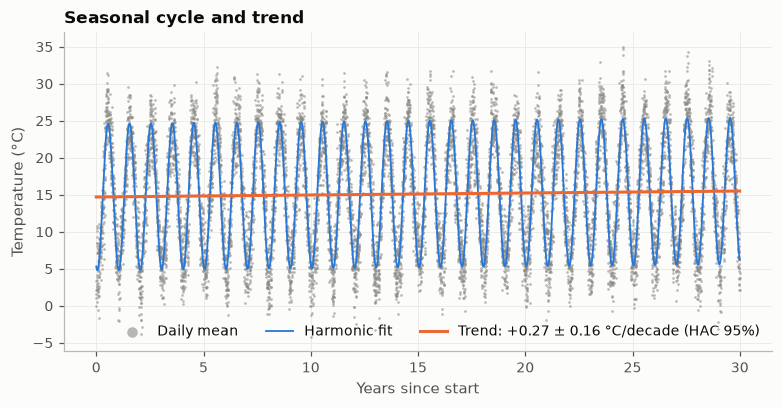

In [4]:
from pcc_vizforge.plots import diagnostics as D

t = np.arange(len(wx), dtype=float)
fit = timeseries.fit_harmonics(t, wx["temperature_avg"].to_numpy(), n_harmonics=1)
print(f"trend = {fit.trend_per_unit * 3652.5:.3f} °C/decade (true 0.3)")
print(f"  OLS SE {fit.trend_stderr * 3652.5:.3f}  vs  Newey-West SE {fit.trend_stderr_hac * 3652.5:.3f} (lags={fit.hac_lags})")
D.temperature_figure(t, wx["temperature_avg"], fit);

The OLS standard error is several times too small because daily anomalies are persistent. A Mann-Kendall test on annual means avoids the problem:

In [5]:
s = gen.calculate_statistics(wx)
print(s["trend_test_resolution"], "Mann-Kendall p =", f"{s['mann_kendall']['p_value']:.2g}")
print("Sen slope (°C/decade):", round(s["sens_slope_c_per_decade"], 3), "CI", np.round(s["sens_slope_ci_c_per_decade"], 3))

annual Mann-Kendall p = 0.015
Sen slope (°C/decade): 0.257 CI [0.076 0.468]


## Coverage of the two standard errors (Monte Carlo)

In [6]:
from pcc_vizforge.experiments.validation import run_study

run_study("trend_hac", n_replicates=150, seed=SEED).summary[["phi", "method", "coverage_95", "coverage_mcse"]].round(3)

,phi,method,coverage_95,coverage_mcse
0,0.0,hac,0.967,0.015
1,0.0,ols,0.973,0.013
2,0.4,hac,0.947,0.018
3,0.4,ols,0.840,0.030
4,0.7,hac,0.933,0.020
5,0.7,ols,0.553,0.041
6,0.9,hac,0.907,0.024
7,0.9,ols,0.307,0.038
